# Laboratorio 2: MNIST, Fashion-MNIST y CNN

**Propósito:** comparar la dificultad de la tarea con la arquitectura fija (Partes 1–2), y después cambiar la arquitectura sobre Fashion-MNIST (Parte 3). La Parte 4 estudia dropout.

Este notebook contiene todo el código del laboratorio. Los modelos se entrenan desde cero; las métricas, gráficas y el reporte final se calculan al ejecutar las celdas.

**Para ejecutar:** desde esta carpeta, abre Jupyter con `.\.venv\Scripts\python.exe -m jupyter lab`, selecciona el kernel **Python (Lab 2)** y usa **Restart Kernel and Run All Cells**. También puedes seleccionar `.venv\Scripts\python.exe` en el editor. Ejecuta en orden para reproducir la secuencia aleatoria completa.

Fuentes locales: [PDF oficial](Lab2-MNIST_FashionMNIST_CNN.pdf), [contexto corregido](CONTEXTO_FINAL_LAB2_MNIST_FASHION_CNN.md), [MNIST de clase](referencias_clase/Pytorch-Mnist-V1.ipynb) y [train/validation de clase](referencias_clase/PytorchBreastCancer_NoComment.ipynb). Los notebooks de referencia se copiaron sin cambios desde Downloads.

## Preparación y configuración común

Los valores se leyeron en **Pytorch-Mnist-V1.ipynb**: celda 5 (batch size), celda 7 (Adam y learning rate), celda 8 (épocas) y celda 3 (validación); los índices de celda empiezan en cero. El PDF exige conservar la configuración, pero no cambia estos valores.

| Hiperparámetro | Valor |
|---|---:|
| Batch size | 32 |
| Optimizador | Adam, valores predeterminados excepto lr |
| Learning rate | 0.001 |
| Épocas | 10 |
| Loss | CrossEntropyLoss |
| Fracción de validación del archivo train | 0.20 |
| Seed / random_state | 42 |

El PDF pide llamar a `torch.manual_seed(42)` **una sola vez**, antes de construir modelos. Las nuevas instancias reciben nuevas inicializaciones dentro de esa secuencia reproducible; la semilla global no significa pesos iniciales idénticos entre experimentos.

Se usa CUDA si está disponible. Esto solo cambia dónde se realizan las operaciones. La reproducibilidad numérica puede variar entre dispositivos o versiones de PyTorch.

In [1]:
get_ipython().run_line_magic("matplotlib", "inline")

import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from dotenv import load_dotenv
from IPython.display import display, Markdown

RANDOM_SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCH_COUNT = 10
VALIDATION_SIZE = 0.2

# Cuatro hilos evitan exceso de paralelismo en estos batches pequeños de CPU.
torch.set_num_threads(4)
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

print("PyTorch:", torch.__version__)
print("Dispositivo:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Batch:", BATCH_SIZE, "| Adam lr:", LEARNING_RATE, "| Épocas:", EPOCH_COUNT)

PyTorch: 2.6.0+cpu
Dispositivo: cpu
Batch: 32 | Adam lr: 0.001 | Épocas: 10


### Carga y verificación de los cuatro archivos

Los datos se leen únicamente desde los cuatro archivos locales mediante `np.load`. Si falta un archivo, una llave o el formato esperado, esta celda se detiene.

El test de MNIST del Laboratorio 1 se reutiliza solamente como test. Los archivos train se dividirán en **48 000 imágenes de entrenamiento y 12 000 de validación**; cada test conserva sus **10 000 imágenes**.

En Fashion se usan las rutas `fmnist_*`: esto corrige la errata de la tarea 2.1 del PDF.

In [2]:
if not load_dotenv(".env", override=True):
    raise FileNotFoundError("No se pudo cargar .env desde la carpeta del notebook.")

mnist_train_fp = os.getenv("MNIST_TRAIN_FILEPATH")
mnist_test_fp = os.getenv("MNIST_TEST_FILEPATH")
fmnist_train_fp = os.getenv("FMNIST_TRAIN_FILEPATH")
fmnist_test_fp = os.getenv("FMNIST_TEST_FILEPATH")

for filepath in [mnist_train_fp, mnist_test_fp, fmnist_train_fp, fmnist_test_fp]:
    if not filepath or not os.path.isfile(filepath):
        raise FileNotFoundError(f"Ruta ausente o inválida: {filepath}")

mnist_train = np.load(mnist_train_fp, allow_pickle=False)
mnist_test = np.load(mnist_test_fp, allow_pickle=False)
fmnist_train = np.load(fmnist_train_fp, allow_pickle=False)
fmnist_test = np.load(fmnist_test_fp, allow_pickle=False)

for name, dataset, expected_size in [
    ("MNIST train", mnist_train, 60000),
    ("MNIST test", mnist_test, 10000),
    ("Fashion train", fmnist_train, 60000),
    ("Fashion test", fmnist_test, 10000),
]:
    if not {"images", "labels"}.issubset(dataset.files):
        raise ValueError(f"{name}: faltan images o labels.")
    images = dataset["images"]
    labels = dataset["labels"]

    print(f"\n{name} | llaves: {dataset.files}")
    print("images:", images.shape, images.dtype, "| píxeles:", images.min(), images.max())
    print("labels:", labels.shape, labels.dtype, "| etiquetas:", labels.min(), labels.max())

    assert images.shape == (expected_size, 28, 28), f"{name}: forma de images inesperada"
    assert labels.shape == (expected_size,), f"{name}: forma de labels inesperada"
    assert np.issubdtype(images.dtype, np.number), f"{name}: imágenes no numéricas"
    assert np.isfinite(images).all(), f"{name}: píxeles no finitos"
    assert 0 <= images.min() and 1 < images.max() <= 255, f"{name}: rango de píxeles inesperado"
    assert np.issubdtype(labels.dtype, np.integer), f"{name}: etiquetas no enteras"
    assert np.array_equal(np.unique(labels), np.arange(10)), f"{name}: clases inesperadas"

del images, labels
print("\nLos cuatro archivos cumplen el formato esperado.")


MNIST train | llaves: ['images', 'labels']


images: (60000, 28, 28) uint8 | píxeles: 0 255
labels: (60000,) uint8 | etiquetas: 0 9

MNIST test | llaves: ['images', 'labels']
images: (10000, 28, 28) uint8 | píxeles: 0 255
labels: (10000,) uint8 | etiquetas: 0 9



Fashion train | llaves: ['images', 'labels']
images: (60000, 28, 28) int64 | píxeles: 0 255
labels: (60000,) int64 | etiquetas: 0 9



Fashion test | llaves: ['images', 'labels']
images: (10000, 28, 28) int64 | píxeles: 0 255
labels: (10000,) int64 | etiquetas: 0 9

Los cuatro archivos cumplen el formato esperado.


## Parte 1 — DenseNet en MNIST

### 1.2 Dividir, escalar y convertir a tensores

Seguimos la secuencia de clase: aplanar, dividir **solo train**, dividir píxeles entre 255.0, crear tensores y luego DataLoaders.

La entrada densa tiene forma `(batch, 784)` y tipo `float32`. Las etiquetas tienen forma `(batch,)` y tipo `long`: cada número es el índice de la clase.

In [3]:
mnist_train_images = mnist_train["images"]
mnist_train_labels = mnist_train["labels"]
mnist_test_images = mnist_test["images"]
mnist_test_labels = mnist_test["labels"]
mnist_train.close()
mnist_test.close()

X_mnist_full = mnist_train_images.reshape(-1, 784).astype(np.float32)
y_mnist_full = mnist_train_labels.astype(np.int64)
X_mnist_test = mnist_test_images.reshape(-1, 784).astype(np.float32)
y_mnist_test = mnist_test_labels.astype(np.int64)

X_mnist_train, X_mnist_val, y_mnist_train, y_mnist_val = train_test_split(
    X_mnist_full, y_mnist_full,
    test_size=VALIDATION_SIZE, random_state=RANDOM_SEED, stratify=y_mnist_full
)

X_mnist_train_tensor = torch.from_numpy(X_mnist_train / 255.0).float()
X_mnist_val_tensor = torch.from_numpy(X_mnist_val / 255.0).float()
X_mnist_test_tensor = torch.from_numpy(X_mnist_test / 255.0).float()

y_mnist_train_tensor = torch.from_numpy(y_mnist_train).long()
y_mnist_val_tensor = torch.from_numpy(y_mnist_val).long()
y_mnist_test_tensor = torch.from_numpy(y_mnist_test).long()

mnist_train_loader = DataLoader(
    TensorDataset(X_mnist_train_tensor, y_mnist_train_tensor),
    batch_size=BATCH_SIZE, shuffle=True
)
mnist_val_loader = DataLoader(
    TensorDataset(X_mnist_val_tensor, y_mnist_val_tensor),
    batch_size=BATCH_SIZE, shuffle=False
)
mnist_test_loader = DataLoader(
    TensorDataset(X_mnist_test_tensor, y_mnist_test_tensor),
    batch_size=BATCH_SIZE, shuffle=False
)

print("Train:", X_mnist_train_tensor.shape, y_mnist_train_tensor.shape)
print("Validation:", X_mnist_val_tensor.shape, y_mnist_val_tensor.shape)
print("Test:", X_mnist_test_tensor.shape, y_mnist_test_tensor.shape)
print("Tipos:", X_mnist_train_tensor.dtype, y_mnist_train_tensor.dtype)
print("Rango normalizado:", X_mnist_train_tensor.min().item(), X_mnist_train_tensor.max().item())

Train: torch.Size([48000, 784]) torch.Size([48000])
Validation: torch.Size([12000, 784]) torch.Size([12000])
Test: torch.Size([10000, 784]) torch.Size([10000])
Tipos: torch.float32 torch.int64
Rango normalizado: 0.0 1.0


### 1.3 Arquitectura y conteo de parámetros

`784 → Linear(784, 128) → ReLU → Linear(128, 10) → logits`.

Para estudiar: `Linear(a, b)` tiene `a*b` pesos y `b` sesgos. Aquí:
`784*128 + 128 + 128*10 + 10 = 101770`.

La salida contiene diez puntajes crudos. `CrossEntropyLoss` combina internamente log-softmax y la pérdida de clasificación; por eso no agregamos Softmax o Sigmoid. Para predecir basta con `argmax(dim=1)`.

In [4]:
class DenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(784, 128)
        self.layer2 = nn.Linear(128, 10)

    def forward(self, x):
        output = F.relu(self.layer1(x))
        output = self.layer2(output)
        return output


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

### 1.4 Ciclo de entrenamiento y evaluación

Se reutilizan cuatro funciones pequeñas: entrenar, evaluar, graficar y contar parámetros. El ciclo de PyTorch permanece visible.

1. `model.train()` activa el comportamiento de entrenamiento, incluido dropout cuando exista.
2. `optimizer.zero_grad()` limpia gradientes acumulados.
3. `outputs = model(x_batch)` hace el **forward**.
4. `criterion(outputs, y_batch)` calcula la **loss**.
5. `loss.backward()` calcula gradientes por retropropagación.
6. `optimizer.step()` actualiza los parámetros.

En validación y test se usan **ambos**: `model.eval()` cambia el comportamiento de capas como dropout; `torch.no_grad()` evita construir el grafo de gradientes. Ninguno actualiza los pesos.

La pérdida de cada época se promedia por imagen, ponderando cada batch por su tamaño. Con 48 000 y 12 000 imágenes, batch 32 divide exactamente ambos conjuntos y coincide con el promedio por batch de clase. **Test no participa en el training loop.**

In [5]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epoch_count):
    train_loss_history = []
    val_loss_history = []
    start_time = time.perf_counter()

    for epoch in range(epoch_count):
        model.train()
        train_running_loss = 0.0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)                 # forward
            loss = criterion(outputs, y_batch)       # loss
            loss.backward()                          # backward
            optimizer.step()                         # actualizar pesos

            train_running_loss += loss.item() * y_batch.size(0)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch)
                val_running_loss += loss.item() * y_batch.size(0)

        train_epoch_loss = train_running_loss / len(train_loader.dataset)
        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        train_loss_history.append(train_epoch_loss)
        val_loss_history.append(val_epoch_loss)

        print(
            f"Época {epoch + 1:2d}/{epoch_count} | "
            f"Train loss: {train_epoch_loss:.4f} | "
            f"Validation loss: {val_epoch_loss:.4f}",
            flush=True
        )

    print(f"Tiempo: {time.perf_counter() - start_time:.1f} segundos", flush=True)
    return {"train_loss": train_loss_history, "val_loss": val_loss_history}


def evaluate_model(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            predictions = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * y_batch.size(0)
            correct += (predictions == y_batch).sum().item()
            true_labels.append(y_batch.cpu())
            predicted_labels.append(predictions.cpu())

    return {
        "loss": running_loss / len(data_loader.dataset),
        "accuracy": correct / len(data_loader.dataset),
        "y_true": torch.cat(true_labels).numpy(),
        "y_pred": torch.cat(predicted_labels).numpy()
    }


def plot_losses(history, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], marker="o", label="Train loss")
    ax.plot(epochs, history["val_loss"], marker="o", label="Validation loss")
    ax.set(xlabel="Época", ylabel="Cross-entropy", title=title)
    ax.set_xticks(list(epochs))
    ax.legend()
    ax.grid(alpha=0.25)

In [6]:
mnist_model = DenseNet().to(device)  # nueva inicialización; entrenamiento desde cero
mnist_optimizer = optim.Adam(mnist_model.parameters(), lr=LEARNING_RATE)

assert count_parameters(mnist_model) == 101770
print(mnist_model)
print("Parámetros:", count_parameters(mnist_model))

mnist_history = train_model(
    mnist_model, mnist_train_loader, mnist_val_loader,
    criterion, mnist_optimizer, EPOCH_COUNT
)

DenseNet(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)
Parámetros: 101770


Época  1/10 | Train loss: 0.3182 | Validation loss: 0.1785


Época  2/10 | Train loss: 0.1437 | Validation loss: 0.1352


Época  3/10 | Train loss: 0.0977 | Validation loss: 0.1140


Época  4/10 | Train loss: 0.0725 | Validation loss: 0.1025


...

Época  7/10 | Train loss: 0.0349 | Validation loss: 0.0960


Época  8/10 | Train loss: 0.0267 | Validation loss: 0.0879


Época  9/10 | Train loss: 0.0215 | Validation loss: 0.0922


Época 10/10 | Train loss: 0.0190 | Validation loss: 0.0961


Tiempo: 23.5 segundos


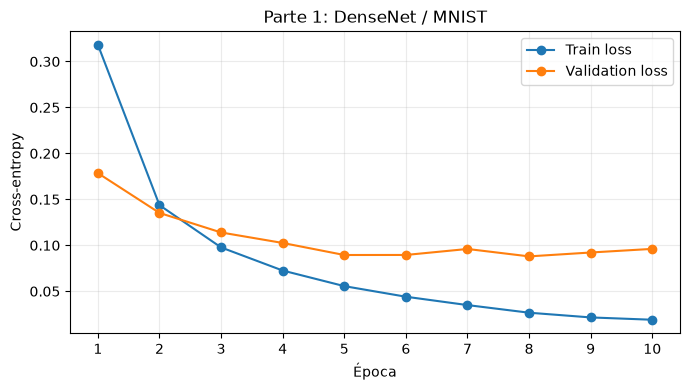

MNIST test loss: 0.0843
MNIST test accuracy: 97.81%


In [7]:
plot_losses(mnist_history, "Parte 1: DenseNet / MNIST")
plt.tight_layout()
plt.show()

# Test se evalúa después de completar las diez épocas.
mnist_result = evaluate_model(mnist_model, mnist_test_loader, criterion)
print(f"MNIST test loss: {mnist_result['loss']:.4f}")
print(f"MNIST test accuracy: {mnist_result['accuracy']:.2%}")

## Parte 2 — La misma DenseNet en Fashion-MNIST

### 2.1 Preparación idéntica

Se repiten los mismos pasos de MNIST y el mismo `train_test_split` estratificado. Las clases son prendas, aunque se mantienen diez índices de clase y 784 entradas.

Para comparar las arquitecturas después, la CNN utilizará **exactamente estas mismas muestras** de entrenamiento, validación y test, reorganizando únicamente la forma de los tensores.

In [8]:
fashion_train_images = fmnist_train["images"]
fashion_train_labels = fmnist_train["labels"]
fashion_test_images = fmnist_test["images"]
fashion_test_labels = fmnist_test["labels"]
fmnist_train.close()
fmnist_test.close()

fashion_classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

X_fashion_full = fashion_train_images.reshape(-1, 784).astype(np.float32)
y_fashion_full = fashion_train_labels.astype(np.int64)
X_fashion_test = fashion_test_images.reshape(-1, 784).astype(np.float32)
y_fashion_test = fashion_test_labels.astype(np.int64)

X_fashion_train, X_fashion_val, y_fashion_train, y_fashion_val = train_test_split(
    X_fashion_full, y_fashion_full,
    test_size=VALIDATION_SIZE, random_state=RANDOM_SEED, stratify=y_fashion_full
)

X_fashion_train_tensor = torch.from_numpy(X_fashion_train / 255.0).float()
X_fashion_val_tensor = torch.from_numpy(X_fashion_val / 255.0).float()
X_fashion_test_tensor = torch.from_numpy(X_fashion_test / 255.0).float()

y_fashion_train_tensor = torch.from_numpy(y_fashion_train).long()
y_fashion_val_tensor = torch.from_numpy(y_fashion_val).long()
y_fashion_test_tensor = torch.from_numpy(y_fashion_test).long()

fashion_train_loader = DataLoader(
    TensorDataset(X_fashion_train_tensor, y_fashion_train_tensor),
    batch_size=BATCH_SIZE, shuffle=True
)
fashion_val_loader = DataLoader(
    TensorDataset(X_fashion_val_tensor, y_fashion_val_tensor),
    batch_size=BATCH_SIZE, shuffle=False
)
fashion_test_loader = DataLoader(
    TensorDataset(X_fashion_test_tensor, y_fashion_test_tensor),
    batch_size=BATCH_SIZE, shuffle=False
)

print("Train:", X_fashion_train_tensor.shape, y_fashion_train_tensor.shape)
print("Validation:", X_fashion_val_tensor.shape, y_fashion_val_tensor.shape)
print("Test:", X_fashion_test_tensor.shape, y_fashion_test_tensor.shape)
print("Tipos:", X_fashion_train_tensor.dtype, y_fashion_train_tensor.dtype)
print("Rango normalizado:", X_fashion_train_tensor.min().item(), X_fashion_train_tensor.max().item())

Train: torch.Size([48000, 784]) torch.Size([48000])
Validation: torch.Size([12000, 784]) torch.Size([12000])
Test: torch.Size([10000, 784]) torch.Size([10000])
Tipos: torch.float32 torch.int64
Rango normalizado: 0.0 1.0


Una imagen de entrenamiento por clase permite relacionar después las métricas con sus formas visuales. Estas imágenes no se transforman ni aumentan.

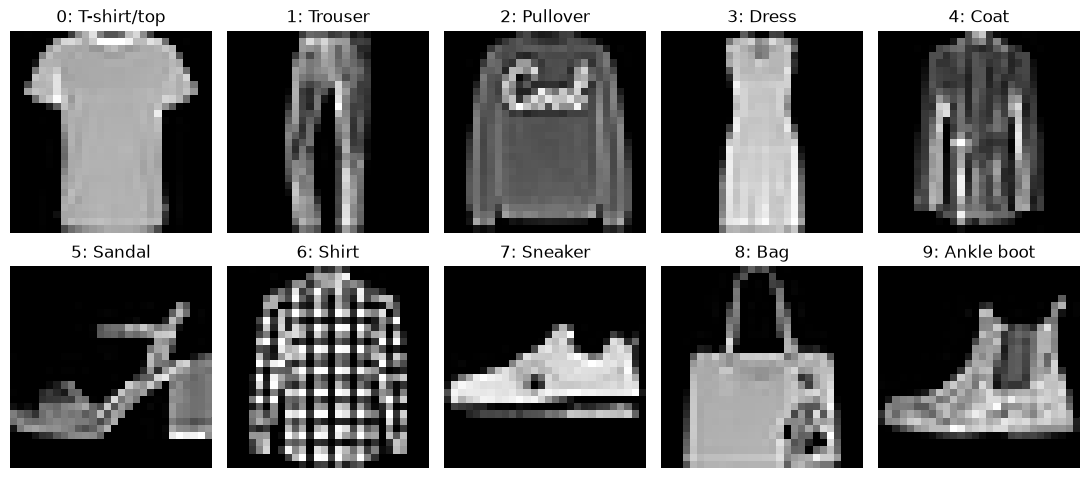

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for class_id, ax in enumerate(axes.flat):
    index = np.flatnonzero(y_fashion_train == class_id)[0]
    ax.imshow(X_fashion_train[index].reshape(28, 28), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{class_id}: {fashion_classes[class_id]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### 2.2 Nueva instancia y entrenamiento

Se construyen una nueva `DenseNet()` y un nuevo Adam. Se conservan las constantes de la Parte 1; no se copian pesos ni el estado del optimizador.

In [10]:
fashion_dense_model = DenseNet().to(device)
fashion_dense_optimizer = optim.Adam(fashion_dense_model.parameters(), lr=LEARNING_RATE)

assert fashion_dense_model is not mnist_model
assert count_parameters(fashion_dense_model) == 101770
print("Parámetros:", count_parameters(fashion_dense_model))

fashion_dense_history = train_model(
    fashion_dense_model, fashion_train_loader, fashion_val_loader,
    criterion, fashion_dense_optimizer, EPOCH_COUNT
)

fashion_dense_result = evaluate_model(fashion_dense_model, fashion_test_loader, criterion)
print(f"Fashion DenseNet test loss: {fashion_dense_result['loss']:.4f}")
print(f"Fashion DenseNet test accuracy: {fashion_dense_result['accuracy']:.2%}")

Parámetros: 101770


Época  1/10 | Train loss: 0.5497 | Validation loss: 0.4263


Época  2/10 | Train loss: 0.4067 | Validation loss: 0.3826


Época  3/10 | Train loss: 0.3665 | Validation loss: 0.4089


Época  4/10 | Train loss: 0.3393 | Validation loss: 0.3537


...

Época  8/10 | Train loss: 0.2785 | Validation loss: 0.3359


Época  9/10 | Train loss: 0.2674 | Validation loss: 0.3510


Época 10/10 | Train loss: 0.2569 | Validation loss: 0.3297


Tiempo: 26.7 segundos


Fashion DenseNet test loss: 0.3249
Fashion DenseNet test accuracy: 87.84%


### 2.3 Comparación de las dos tareas

Las gráficas usan la misma escala vertical. Las conclusiones numéricas se construyen al final, con los resultados ejecutados. Una diferencia entre datasets no se debe a haber cambiado la arquitectura o los hiperparámetros; una sola corrida también conserva variabilidad de optimización.

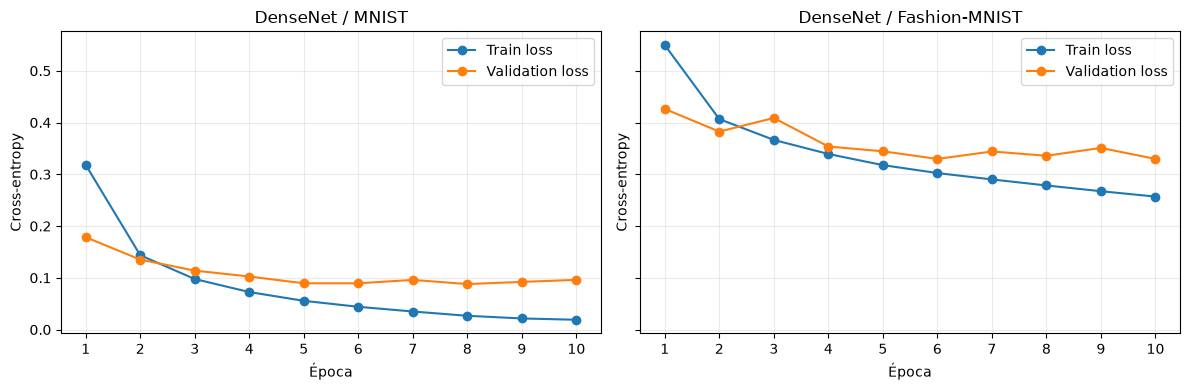

| Dataset | Test accuracy | Train loss final | Validation loss final |
|---|---:|---:|---:|
| MNIST | 97.81% | 0.0190 | 0.0961 |
| Fashion-MNIST | 87.84% | 0.2569 | 0.3297 |

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_losses(mnist_history, "DenseNet / MNIST", axes[0])
plot_losses(fashion_dense_history, "DenseNet / Fashion-MNIST", axes[1])
plt.tight_layout()
plt.show()

table_dense = (
    "| Dataset | Test accuracy | Train loss final | Validation loss final |\n"
    "|---|---:|---:|---:|\n"
    f"| MNIST | {mnist_result['accuracy']:.2%} | {mnist_history['train_loss'][-1]:.4f} | {mnist_history['val_loss'][-1]:.4f} |\n"
    f"| Fashion-MNIST | {fashion_dense_result['accuracy']:.2%} | {fashion_dense_history['train_loss'][-1]:.4f} | {fashion_dense_history['val_loss'][-1]:.4f} |"
)
display(Markdown(table_dense))

## Parte 3 — CNN en Fashion-MNIST

### 3.1–3.4 Estructura espacial y arquitectura exacta

Aplanar es un cambio de forma reversible: los valores de los píxeles siguen presentes. La limitación es que una capa densa **no incorpora explícitamente la vecindad en dos dimensiones ni comparte filtros entre posiciones**. La convolución sí impone esas relaciones.

Los filtros compartidos detectan patrones locales en diferentes ubicaciones. La convolución es aproximadamente equivariante a traslaciones; el pooling aporta tolerancia a pequeños desplazamientos, sin garantizar invariancia completa de toda la CNN.

| Operación | Forma de salida por imagen |
|---|---|
| Entrada | 1 × 28 × 28 |
| Conv2d(1, 16, 3, padding=1) + ReLU | 16 × 28 × 28 |
| MaxPool2d(2) | 16 × 14 × 14 |
| Conv2d(16, 32, 3, padding=1) + ReLU | 32 × 14 × 14 |
| MaxPool2d(2) | 32 × 7 × 7 |
| Flatten | 1568 |
| Linear(1568, 10) | 10 logits |

Parámetros: conv1 = `16*(1*3*3 + 1) = 160`; conv2 = `32*(16*3*3 + 1) = 4640`; salida = `1568*10 + 10 = 15690`. Total: **20 490**. ReLU, pooling y flatten no tienen parámetros aprendibles.

In [12]:
# view cambia la forma, conserva los valores y la división de datos de la Parte 2.
X_fashion_train_cnn = X_fashion_train_tensor.view(-1, 1, 28, 28)
X_fashion_val_cnn = X_fashion_val_tensor.view(-1, 1, 28, 28)
X_fashion_test_cnn = X_fashion_test_tensor.view(-1, 1, 28, 28)

cnn_train_loader = DataLoader(
    TensorDataset(X_fashion_train_cnn, y_fashion_train_tensor),
    batch_size=BATCH_SIZE, shuffle=True
)
cnn_val_loader = DataLoader(
    TensorDataset(X_fashion_val_cnn, y_fashion_val_tensor),
    batch_size=BATCH_SIZE, shuffle=False
)
cnn_test_loader = DataLoader(
    TensorDataset(X_fashion_test_cnn, y_fashion_test_tensor),
    batch_size=BATCH_SIZE, shuffle=False
)

print("Train CNN:", X_fashion_train_cnn.shape)
print("Validation CNN:", X_fashion_val_cnn.shape)
print("Test CNN:", X_fashion_test_cnn.shape)

Train CNN: torch.Size([48000, 1, 28, 28])
Validation CNN: torch.Size([12000, 1, 28, 28])
Test CNN: torch.Size([10000, 1, 28, 28])


In [13]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.fc_out = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        output = self.pool(F.relu(self.conv1(x)))
        output = self.pool(F.relu(self.conv2(output)))
        output = output.view(output.size(0), -1)
        output = self.fc_out(output)
        return output

### 3.5 Entrenar, evaluar y comparar

La CNN usa el mismo split, CrossEntropyLoss, Adam, learning rate, batch size y diez épocas. Se imprime un recorrido por las dimensiones antes de entrenar para comprobar la arquitectura.

In [14]:
fashion_cnn_model = ConvNet().to(device)
fashion_cnn_optimizer = optim.Adam(fashion_cnn_model.parameters(), lr=LEARNING_RATE)

assert count_parameters(fashion_cnn_model) == 20490
print(fashion_cnn_model)
print("Parámetros:", count_parameters(fashion_cnn_model))

with torch.no_grad():
    example = X_fashion_train_cnn[:BATCH_SIZE].to(device)
    conv1_output = fashion_cnn_model.pool(F.relu(fashion_cnn_model.conv1(example)))
    conv2_output = fashion_cnn_model.pool(F.relu(fashion_cnn_model.conv2(conv1_output)))
    flattened = conv2_output.view(conv2_output.size(0), -1)
    logits = fashion_cnn_model.fc_out(flattened)
    assert conv1_output.shape == (BATCH_SIZE, 16, 14, 14)
    assert conv2_output.shape == (BATCH_SIZE, 32, 7, 7)
    assert flattened.shape == (BATCH_SIZE, 1568)
    assert logits.shape == (BATCH_SIZE, 10)
    for name, tensor in [
        ("Entrada", example), ("Conv1 + pool", conv1_output),
        ("Conv2 + pool", conv2_output), ("Flatten", flattened), ("Logits", logits)
    ]:
        print(name, tuple(tensor.shape))

fashion_cnn_history = train_model(
    fashion_cnn_model, cnn_train_loader, cnn_val_loader,
    criterion, fashion_cnn_optimizer, EPOCH_COUNT
)

fashion_cnn_result = evaluate_model(fashion_cnn_model, cnn_test_loader, criterion)
print(f"Fashion CNN test loss: {fashion_cnn_result['loss']:.4f}")
print(f"Fashion CNN test accuracy: {fashion_cnn_result['accuracy']:.2%}")

ConvNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc_out): Linear(in_features=1568, out_features=10, bias=True)
)
Parámetros: 20490
Entrada (32, 1, 28, 28)
Conv1 + pool (32, 16, 14, 14)
Conv2 + pool (32, 32, 7, 7)
Flatten (32, 1568)
Logits (32, 10)


Época  1/10 | Train loss: 0.4958 | Validation loss: 0.3713


Época  2/10 | Train loss: 0.3346 | Validation loss: 0.3116


Época  3/10 | Train loss: 0.2928 | Validation loss: 0.2890


Época  4/10 | Train loss: 0.2681 | Validation loss: 0.3167


...

Época  8/10 | Train loss: 0.2070 | Validation loss: 0.2566


Época  9/10 | Train loss: 0.1969 | Validation loss: 0.2681


Época 10/10 | Train loss: 0.1896 | Validation loss: 0.2612


Tiempo: 131.5 segundos


Fashion CNN test loss: 0.2505
Fashion CNN test accuracy: 90.80%


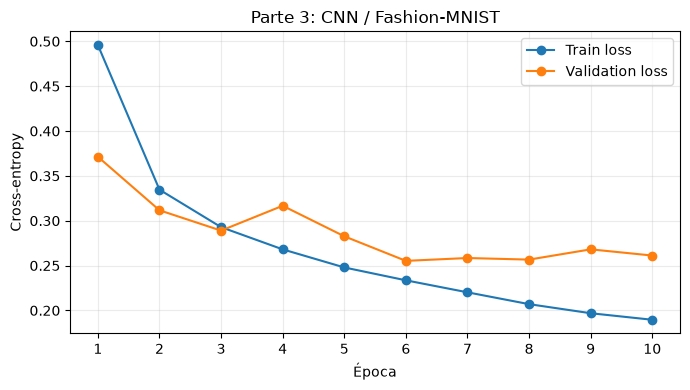

| Modelo / Dataset | Test accuracy | Parámetros |
|---|---:|---:|
| DenseNet / MNIST | 97.81% | 101770 |
| DenseNet / Fashion-MNIST | 87.84% | 101770 |
| CNN / Fashion-MNIST | 90.80% | 20490 |

Brecha Dense MNIST - Dense Fashion: 9.97 puntos porcentuales
Ganancia CNN Fashion - Dense Fashion: 2.96 puntos porcentuales
Brecha Dense MNIST - CNN Fashion: 7.01 puntos porcentuales
Fracción de la brecha recuperada: 29.69%


In [15]:
plot_losses(fashion_cnn_history, "Parte 3: CNN / Fashion-MNIST")
plt.tight_layout()
plt.show()

table_models = (
    "| Modelo / Dataset | Test accuracy | Parámetros |\n"
    "|---|---:|---:|\n"
    f"| DenseNet / MNIST | {mnist_result['accuracy']:.2%} | {count_parameters(mnist_model)} |\n"
    f"| DenseNet / Fashion-MNIST | {fashion_dense_result['accuracy']:.2%} | {count_parameters(fashion_dense_model)} |\n"
    f"| CNN / Fashion-MNIST | {fashion_cnn_result['accuracy']:.2%} | {count_parameters(fashion_cnn_model)} |"
)
display(Markdown(table_models))

gap_pp = 100 * (mnist_result["accuracy"] - fashion_dense_result["accuracy"])
cnn_gain_pp = 100 * (fashion_cnn_result["accuracy"] - fashion_dense_result["accuracy"])
remaining_gap_pp = 100 * (mnist_result["accuracy"] - fashion_cnn_result["accuracy"])

print(f"Brecha Dense MNIST - Dense Fashion: {gap_pp:.2f} puntos porcentuales")
print(f"Ganancia CNN Fashion - Dense Fashion: {cnn_gain_pp:.2f} puntos porcentuales")
print(f"Brecha Dense MNIST - CNN Fashion: {remaining_gap_pp:.2f} puntos porcentuales")
if gap_pp > 0:
    print(f"Fracción de la brecha recuperada: {100 * cnn_gain_pp / gap_pp:.2f}%")

### 3.6–3.7 Precision, recall y F1 por clase

Para una clase: **precision** = TP/(TP+FP), **recall** = TP/(TP+FN) y **F1** = 2·precision·recall/(precision+recall). Accuracy es la fracción total de aciertos; no describe en qué clases se concentran los errores.

Se reutilizan las predicciones de test ya calculadas para la CNN. El reporte contiene precision, recall, F1 y support. Para responder qué pares se confunden, también contamos las predicciones incorrectas por par: un F1 bajo por sí solo no identifica la clase con la que se confunde.

In [16]:
y_true = fashion_cnn_result["y_true"]
y_pred = fashion_cnn_result["y_pred"]

report_text = classification_report(
    y_true, y_pred, labels=list(range(10)), target_names=fashion_classes,
    digits=4, zero_division=0
)
print(report_text)

class_metrics = classification_report(
    y_true, y_pred, labels=list(range(10)), target_names=fashion_classes,
    output_dict=True, zero_division=0
)

table_classes = "| Clase | Precision | Recall | F1 | Support |\n|---|---:|---:|---:|---:|\n"
for name in fashion_classes:
    metrics = class_metrics[name]
    table_classes += (
        f"| {name} | {metrics['precision']:.4f} | {metrics['recall']:.4f} | "
        f"{metrics['f1-score']:.4f} | {int(metrics['support'])} |\n"
    )
display(Markdown(table_classes))

f1_scores = np.array([class_metrics[name]["f1-score"] for name in fashion_classes])
lowest_classes = [fashion_classes[i] for i in np.flatnonzero(f1_scores == f1_scores.min())]
highest_classes = [fashion_classes[i] for i in np.flatnonzero(f1_scores == f1_scores.max())]
print("F1 más bajo:", ", ".join(lowest_classes), f"({f1_scores.min():.4f})")
print("F1 más alto:", ", ".join(highest_classes), f"({f1_scores.max():.4f})")

# Conteos dirigidos: la primera clase es la verdadera y la segunda la predicha.
confusions = []
for true_id in range(10):
    for predicted_id in range(10):
        if true_id != predicted_id:
            amount = int(np.sum((y_true == true_id) & (y_pred == predicted_id)))
            confusions.append((amount, fashion_classes[true_id], fashion_classes[predicted_id]))
confusions.sort(reverse=True)

print("\nCinco confusiones más frecuentes (real -> predicha):")
for amount, real_name, predicted_name in confusions[:5]:
    print(f"{real_name} -> {predicted_name}: {amount}")

similar_names = ["T-shirt/top", "Pullover", "Coat", "Shirt"]
distinct_names = ["Trouser", "Sandal", "Bag"]
similar_f1 = np.mean([class_metrics[name]["f1-score"] for name in similar_names])
distinct_f1 = np.mean([class_metrics[name]["f1-score"] for name in distinct_names])
print(f"F1 promedio camiseta/suéter/abrigo/camisa: {similar_f1:.4f}")
print(f"F1 promedio pantalón/sandalia/bolso: {distinct_f1:.4f}")

              precision    recall  f1-score   support

 T-shirt/top     0.8165    0.8900    0.8517      1000
     Trouser     0.9754    0.9910    0.9831      1000
    Pullover     0.8406    0.8860    0.8627      1000
       Dress     0.9515    0.8820    0.9154      1000
        Coat     0.8242    0.9140    0.8668      1000
      Sandal     0.9937    0.9470    0.9698      1000
       Shirt     0.8109    0.6560    0.7253      1000
     Sneaker     0.9439    0.9590    0.9514      1000
         Bag     0.9869    0.9830    0.9850      1000
  Ankle boot     0.9437    0.9720    0.9576      1000

    accuracy                         0.9080     10000
   macro avg     0.9087    0.9080    0.9069     10000
weighted avg     0.9087    0.9080    0.9069     10000



| Clase | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|
| T-shirt/top | 0.8165 | 0.8900 | 0.8517 | 1000 |
| Trouser | 0.9754 | 0.9910 | 0.9831 | 1000 |
| Pullover | 0.8406 | 0.8860 | 0.8627 | 1000 |
| Dress | 0.9515 | 0.8820 | 0.9154 | 1000 |
| Coat | 0.8242 | 0.9140 | 0.8668 | 1000 |
| Sandal | 0.9937 | 0.9470 | 0.9698 | 1000 |
| Shirt | 0.8109 | 0.6560 | 0.7253 | 1000 |
| Sneaker | 0.9439 | 0.9590 | 0.9514 | 1000 |
| Bag | 0.9869 | 0.9830 | 0.9850 | 1000 |
| Ankle boot | 0.9437 | 0.9720 | 0.9576 | 1000 |


F1 más bajo: Shirt (0.7253)
F1 más alto: Bag (0.9850)

Cinco confusiones más frecuentes (real -> predicha):
Shirt -> T-shirt/top: 142
Shirt -> Coat: 93
Shirt -> Pullover: 89
T-shirt/top -> Shirt: 71
Pullover -> Coat: 64
F1 promedio camiseta/suéter/abrigo/camisa: 0.8266
F1 promedio pantalón/sandalia/bolso: 0.9793


## Parte 4 — Dropout después de flatten y antes de fc_out

`nn.Dropout(p)` pone activaciones a cero con probabilidad `p` durante el entrenamiento y reescala las que conserva. Con `model.eval()` actúa como identidad. **No añade parámetros aprendibles.**

Se entrenan cuatro modelos nuevos con `p = 0.0, 0.2, 0.4, 0.6`, el mismo split y la configuración común. La corrida con `p=0.0` también empieza desde cero: no reutiliza los pesos de la Parte 3. Puede dar otro resultado porque avanza la secuencia aleatoria iniciada una sola vez, como indica el PDF.

Test se consulta una vez al terminar cada modelo para completar la tabla solicitada. No se utiliza para elegir épocas o modificar hiperparámetros.

In [17]:
class ConvNetDropout(nn.Module):
    def __init__(self, dropout_p):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc_out = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        output = self.pool(F.relu(self.conv1(x)))
        output = self.pool(F.relu(self.conv2(output)))
        output = output.view(output.size(0), -1)
        output = self.dropout(output)
        output = self.fc_out(output)
        return output

In [18]:
dropout_rates = [0.0, 0.2, 0.4, 0.6]
dropout_histories = {}
dropout_results = {}

for dropout_p in dropout_rates:
    print(f"\nDropout p = {dropout_p:.1f}", flush=True)
    dropout_model = ConvNetDropout(dropout_p).to(device)
    dropout_optimizer = optim.Adam(dropout_model.parameters(), lr=LEARNING_RATE)
    assert count_parameters(dropout_model) == 20490

    dropout_histories[dropout_p] = train_model(
        dropout_model, cnn_train_loader, cnn_val_loader,
        criterion, dropout_optimizer, EPOCH_COUNT
    )
    dropout_results[dropout_p] = evaluate_model(dropout_model, cnn_test_loader, criterion)
    print(f"Test accuracy: {dropout_results[dropout_p]['accuracy']:.2%}", flush=True)


Dropout p = 0.0


Época  1/10 | Train loss: 0.5089 | Validation loss: 0.3870


Época  2/10 | Train loss: 0.3400 | Validation loss: 0.3231


Época  3/10 | Train loss: 0.3000 | Validation loss: 0.3018


Época  4/10 | Train loss: 0.2760 | Validation loss: 0.2937


...

Época  8/10 | Train loss: 0.3107 | Validation loss: 0.2765


Época  9/10 | Train loss: 0.3063 | Validation loss: 0.2673


Época 10/10 | Train loss: 0.3003 | Validation loss: 0.2677


Tiempo: 138.1 segundos


Test accuracy: 90.70%


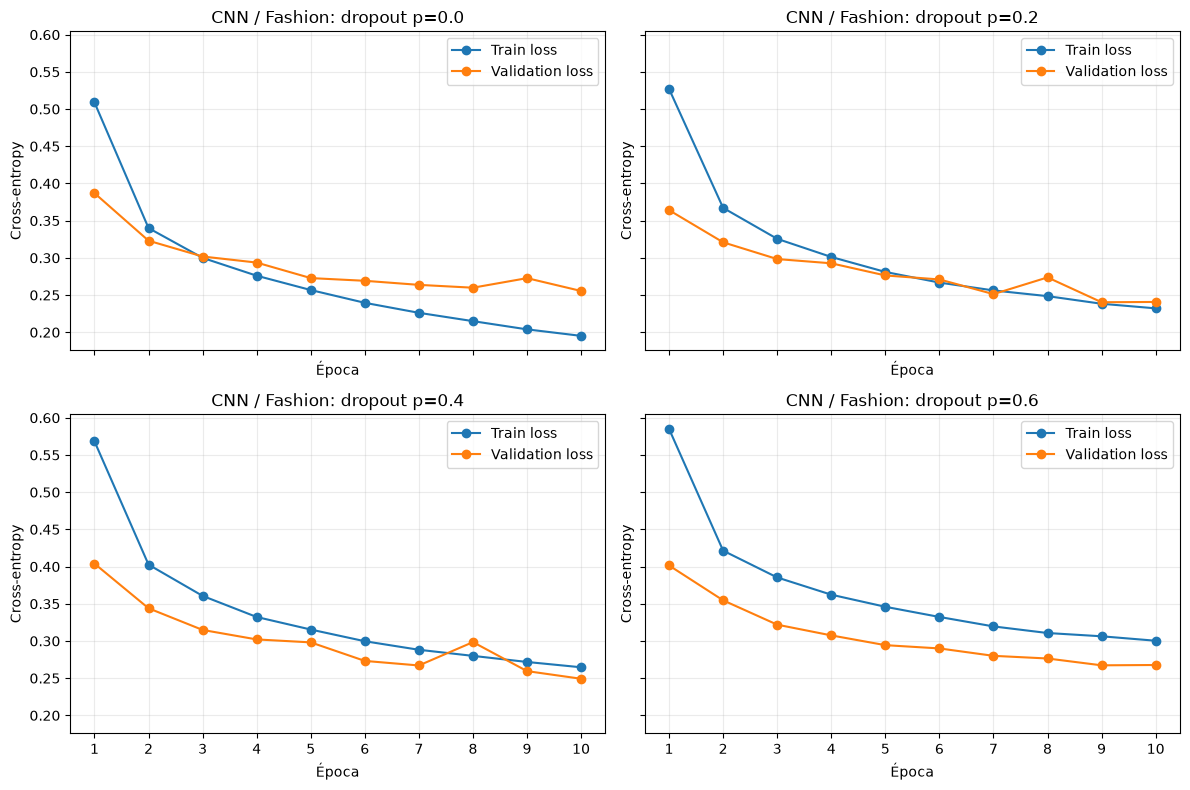

| Dropout p | Test accuracy | Train loss final | Validation loss final | Val - train |
|---:|---:|---:|---:|---:|
| 0.0 | 91.26% | 0.1952 | 0.2555 | +0.0603 |
| 0.2 | 91.85% | 0.2321 | 0.2407 | +0.0086 |
| 0.4 | 91.55% | 0.2647 | 0.2492 | -0.0154 |
| 0.6 | 90.70% | 0.3003 | 0.2677 | -0.0326 |


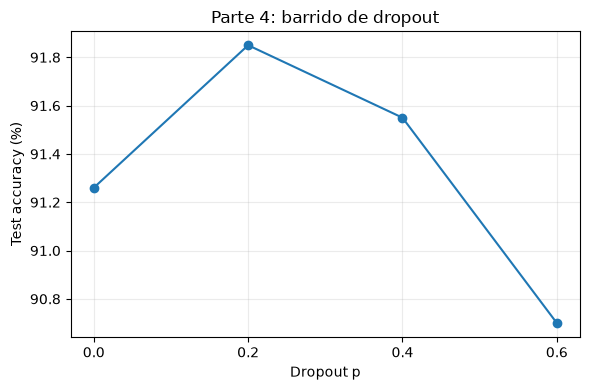

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for dropout_p, ax in zip(dropout_rates, axes.flat):
    plot_losses(dropout_histories[dropout_p], f"CNN / Fashion: dropout p={dropout_p:.1f}", ax)
plt.tight_layout()
plt.show()

table_dropout = (
    "| Dropout p | Test accuracy | Train loss final | Validation loss final | Val - train |\n"
    "|---:|---:|---:|---:|---:|\n"
)
dropout_gaps = []
for dropout_p in dropout_rates:
    train_loss = dropout_histories[dropout_p]["train_loss"][-1]
    val_loss = dropout_histories[dropout_p]["val_loss"][-1]
    dropout_gaps.append(val_loss - train_loss)
    table_dropout += (
        f"| {dropout_p:.1f} | {dropout_results[dropout_p]['accuracy']:.2%} | "
        f"{train_loss:.4f} | {val_loss:.4f} | {val_loss - train_loss:+.4f} |\n"
    )
display(Markdown(table_dropout))

plt.figure(figsize=(6, 4))
plt.plot(
    dropout_rates,
    [100 * dropout_results[p]["accuracy"] for p in dropout_rates],
    marker="o"
)
plt.xticks(dropout_rates)
plt.xlabel("Dropout p")
plt.ylabel("Test accuracy (%)")
plt.title("Parte 4: barrido de dropout")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 4.2 Cómo interpretar las curvas

La train loss se mide durante las actualizaciones y con dropout activo; la validation loss se mide al final de la época con dropout desactivado. Una brecha menor, o incluso negativa, no demuestra por sí sola una mejor generalización: dropout también hace más difícil el forward de entrenamiento.

Una corrida por tasa permite describir diferencias, pero no estimar su significancia estadística ni el margen de variabilidad. Si se destaca una tasa como candidata, se usa la menor **validation loss final**; los resultados de test del barrido se presentan descriptivamente.

## Discusión y reporte

La siguiente celda se ejecuta después de los siete entrenamientos. Construye las respuestas con las métricas obtenidas y guarda `reporte_lab2.md` con una discusión breve y las tablas requeridas. Los valores no están escritos de antemano.

In [20]:
# Resúmenes calculados exclusivamente a partir de esta ejecución.
if gap_pp <= 0:
    recovery_text = "no hubo una caída positiva entre las dos redes densas que recuperar"
elif cnn_gain_pp <= 0:
    recovery_text = "la CNN no recuperó la brecha"
elif remaining_gap_pp <= 0:
    recovery_text = "la CNN cerró por completo o superó la brecha"
else:
    recovery_text = f"la CNN recuperó parcialmente la brecha ({100 * cnn_gain_pp / gap_pp:.2f}%)"

fashion_loss_relation = (
    "mayor" if fashion_dense_history["train_loss"][-1] > mnist_history["train_loss"][-1]
    else "menor o igual"
)
class_relation = "menor" if similar_f1 < distinct_f1 else "mayor o igual"
top_confusions_text = "; ".join(
    f"{real_name} → {predicted_name}: {amount}"
    for amount, real_name, predicted_name in confusions[:3]
)

best_val_p = min(dropout_rates, key=lambda p: dropout_histories[p]["val_loss"][-1])
dropout_accuracy_values = [dropout_results[p]["accuracy"] for p in dropout_rates]
spread_pp = 100 * (max(dropout_accuracy_values) - min(dropout_accuracy_values))
selected_gain_pp = 100 * (
    dropout_results[best_val_p]["accuracy"] - fashion_cnn_result["accuracy"]
)
sweep_gain_pp = 100 * (
    dropout_results[best_val_p]["accuracy"] - dropout_results[0.0]["accuracy"]
)
gap_trend = (
    "disminuye monótonamente" if np.all(np.diff(dropout_gaps) <= 0)
    else "no disminuye monótonamente"
)
architecture_comparison = (
    "El cambio de arquitectura aporta una ganancia mayor que el incremento de la tasa elegida frente a la CNN de la Parte 3."
    if cnn_gain_pp > selected_gain_pp
    else "En esta corrida, el incremento de la tasa elegida frente a la CNN de la Parte 3 iguala o supera la ganancia del cambio de arquitectura."
)

discussion = f"""# Reporte — Laboratorio 2: MNIST, Fashion-MNIST y CNN

**Método.** Se verificaron los cuatro archivos locales con np.load. Cada archivo train se dividió
en 48 000 imágenes de entrenamiento y 12 000 de validación (20 %, estratificación y random_state=42);
los tests de 10 000 imágenes quedaron separados. Se usaron píxeles/255, etiquetas long,
CrossEntropyLoss, Adam con lr=0.001, batch 32 y 10 épocas, como en el notebook MNIST de clase.
La semilla de PyTorch se fijó una vez en 42; cada modelo se inicializó desde cero.
Los tests se evaluaron después de entrenar.

**Parte 2 — Dificultad y pérdidas.** DenseNet obtuvo {mnist_result['accuracy']:.2%} en MNIST y
{fashion_dense_result['accuracy']:.2%} en Fashion: una diferencia de {gap_pp:.2f} puntos porcentuales.
La arquitectura y los hiperparámetros son los mismos, por lo que no se explica por haber diseñado
una red distinta o cambiado el entrenamiento. La tarea cambia: las prendas pueden compartir
siluetas y detalles difíciles de distinguir. La train loss final de Fashion
({fashion_dense_history['train_loss'][-1]:.4f}) fue {fashion_loss_relation} que la de MNIST
({mnist_history['train_loss'][-1]:.4f}). Esto permite valorar cuánto le cuesta al mismo modelo
ajustar cada tarea; no demuestra incapacidad absoluta ni elimina la variabilidad de una corrida.
Las curvas y validation loss permiten distinguir mejora del ajuste de mejora de generalización.

**Parte 3 — Arquitectura y brecha.** La CNN obtuvo {fashion_cnn_result['accuracy']:.2%}:
ganó {cnn_gain_pp:.2f} puntos frente a Dense Fashion; {recovery_text}.
Quedan {remaining_gap_pp:.2f} puntos entre Dense MNIST y CNN Fashion.
DenseNet tiene {count_parameters(mnist_model):,} parámetros y la CNN {count_parameters(fashion_cnn_model):,}.
La conectividad local y los filtros compartidos incorporan relaciones útiles para las imágenes
con menos pesos. Aplanar conserva los valores, pero la capa densa no incorpora esas relaciones
espaciales de forma explícita. Más parámetros no garantizan mejor generalización.

**Parte 3 — Errores por clase.** El F1 mínimo fue {f1_scores.min():.4f}
({', '.join(lowest_classes)}) y el máximo {f1_scores.max():.4f}
({', '.join(highest_classes)}). Entre las confusiones más frecuentes están:
{top_confusions_text}. El F1 medio de T-shirt/top, Pullover, Coat y Shirt fue {similar_f1:.4f},
{class_relation} que el de Trouser, Sandal y Bag ({distinct_f1:.4f}).
Las primeras comparten contornos y zonas de mangas/torso visibles en los ejemplos; los otros
grupos presentan formas más diferenciadas. El accuracy global oculta esta distribución de errores:
un buen promedio puede coexistir con clases poco fiables. Para valorar un uso real deben
revisarse precision, recall, F1 y el costo de cada error. Rotar o trasladar imágenes podría ayudar
ante cambios de orientación o posición, pero no resuelve por sí solo Shirt frente a T-shirt/top:
hay similitud de categoría y pérdida de detalles a 28×28. Esa hipótesis no se probó con augmentation.

**Parte 4 — Dropout.** El rango entre los test accuracies del barrido fue {spread_pp:.2f} puntos.
La menor validation loss final corresponde a p={best_val_p:.1f}
({dropout_histories[best_val_p]['val_loss'][-1]:.4f}); su test accuracy fue
{dropout_results[best_val_p]['accuracy']:.2%}. Su diferencia con p=0.0 del barrido fue
{sweep_gain_pp:+.2f} puntos y con la CNN de la Parte 3 fue {selected_gain_pp:+.2f} puntos.
La brecha firmada val-train {gap_trend} al aumentar p, y pasa de {dropout_gaps[0]:+.4f}
a {dropout_gaps[-1]:+.4f}. Debe leerse junto con las curvas: train usa dropout activo y
pesos que cambian, mientras validation usa el modelo final de la época sin dropout.
Por eso una brecha menor o negativa no prueba por sí sola mejor generalización.
Una ejecución por tasa no permite establecer significancia ni distinguir con certeza el efecto
de dropout del ruido de inicialización y batches. Las corridas p=0.0 y CNN sin dropout también
tienen inicializaciones distintas dentro de la secuencia de semilla fija.
Fashion proporciona 60 000 imágenes en el archivo train (48 000 usadas para actualizar pesos),
muchas más que las aproximadamente 455 del ejemplo de cáncer de mama; eso puede reducir la
necesidad de regularización, aunque también importan la tarea y la capacidad del modelo.
{architecture_comparison} Estas diferencias describen esta ejecución y no una regla universal.
"""

report_markdown = (
    discussion
    + "\n## Comparación de las Partes 1 y 2\n\n" + table_dense
    + "\n\n## Comparación de los tres modelos\n\n" + table_models
    + "\n\n## Métricas por clase — CNN de la Parte 3\n\n" + table_classes
    + "\n\n## Barrido de dropout\n\n" + table_dropout
    + "\n\nFuentes: PDF del laboratorio; Pytorch-Mnist-V1.ipynb; "
    + "PytorchBreastCancer_NoComment.ipynb. Resultados calculados por este notebook.\n"
)
with open("reporte_lab2.md", "w", encoding="utf-8") as report_file:
    report_file.write(report_markdown)

display(Markdown(discussion))
print("Reporte guardado en reporte_lab2.md")

# Reporte — Laboratorio 2: MNIST, Fashion-MNIST y CNN

**Método.** Se verificaron los cuatro archivos locales con np.load. Cada archivo train se dividió
en 48 000 imágenes de entrenamiento y 12 000 de validación (20 %, estratificación y random_state=42);
los tests de 10 000 imágenes quedaron separados. Se usaron píxeles/255, etiquetas long,
CrossEntropyLoss, Adam con lr=0.001, batch 32 y 10 épocas, como en el notebook MNIST de clase.
La semilla de PyTorch se fijó una vez en 42; cada modelo se inicializó desde cero.
Los tests se evaluaron después de entrenar.

**Parte 2 — Dificultad y pérdidas.** DenseNet obtuvo 97.81% en MNIST y
87.84% en Fashion: una diferencia de 9.97 puntos porcentuales.
La arquitectura y los hiperparámetros son los mismos, por lo que no se explica por haber diseñado
una red distinta o cambiado el entrenamiento. La tarea cambia: las prendas pueden compartir
siluetas y detalles difíciles de distinguir. La train loss final de Fashion
(0.2569) fue mayor que la de MNIST
(0.0190). Esto permite valorar cuánto le cuesta al mismo modelo
ajustar cada tarea; no demuestra incapacidad absoluta ni elimina la variabilidad de una corrida.
Las curvas y validation loss permiten distinguir mejora del ajuste de mejora de generalización.

**Parte 3 — Arquitectura y brecha.** La CNN obtuvo 90.80%:
ganó 2.96 puntos frente a Dense Fashion; la CNN recuperó parcialmente la brecha (29.69%).
Quedan 7.01 puntos entre Dense MNIST y CNN Fashion.
DenseNet tiene 101,770 parámetros y la CNN 20,490.
La conectividad local y los filtros compartidos incorporan relaciones útiles para las imágenes
con menos pesos. Aplanar conserva los valores, pero la capa densa no incorpora esas relaciones
espaciales de forma explícita. Más parámetros no garantizan mejor generalización.

**Parte 3 — Errores por clase.** El F1 mínimo fue 0.7253
(Shirt) y el máximo 0.9850
(Bag). Entre las confusiones más frecuentes están:
Shirt → T-shirt/top: 142; Shirt → Coat: 93; Shirt → Pullover: 89. El F1 medio de T-shirt/top, Pullover, Coat y Shirt fue 0.8266,
menor que el de Trouser, Sandal y Bag (0.9793).
Las primeras comparten contornos y zonas de mangas/torso visibles en los ejemplos; los otros
grupos presentan formas más diferenciadas. El accuracy global oculta esta distribución de errores:
un buen promedio puede coexistir con clases poco fiables. Para valorar un uso real deben
revisarse precision, recall, F1 y el costo de cada error. Rotar o trasladar imágenes podría ayudar
ante cambios de orientación o posición, pero no resuelve por sí solo Shirt frente a T-shirt/top:
hay similitud de categoría y pérdida de detalles a 28×28. Esa hipótesis no se probó con augmentation.

**Parte 4 — Dropout.** El rango entre los test accuracies del barrido fue 1.15 puntos.
La menor validation loss final corresponde a p=0.2
(0.2407); su test accuracy fue
91.85%. Su diferencia con p=0.0 del barrido fue
+0.59 puntos y con la CNN de la Parte 3 fue +1.05 puntos.
La brecha firmada val-train disminuye monótonamente al aumentar p, y pasa de +0.0603
a -0.0326. Debe leerse junto con las curvas: train usa dropout activo y
pesos que cambian, mientras validation usa el modelo final de la época sin dropout.
Por eso una brecha menor o negativa no prueba por sí sola mejor generalización.
Una ejecución por tasa no permite establecer significancia ni distinguir con certeza el efecto
de dropout del ruido de inicialización y batches. Las corridas p=0.0 y CNN sin dropout también
tienen inicializaciones distintas dentro de la secuencia de semilla fija.
Fashion proporciona 60 000 imágenes en el archivo train (48 000 usadas para actualizar pesos),
muchas más que las aproximadamente 455 del ejemplo de cáncer de mama; eso puede reducir la
necesidad de regularización, aunque también importan la tarea y la capacidad del modelo.
El cambio de arquitectura aporta una ganancia mayor que el incremento de la tasa elegida frente a la CNN de la Parte 3. Estas diferencias describen esta ejecución y no una regla universal.


Reporte guardado en reporte_lab2.md


## Repaso para la evaluación escrita

- **Datos:** cargar → separar train/validation → normalizar → tensor → TensorDataset → DataLoader.
- **DenseNet:** dos `Linear`, ReLU solo en la capa oculta; entrada `(B,784)`, salida `(B,10)`.
- **CNN:** conv → ReLU → pool → conv → ReLU → pool → flatten → salida; entrada `(B,1,28,28)`.
- **Entrenar:** train → zero_grad → forward → loss → backward → step.
- **Validar y evaluar:** eval + no_grad → forward → loss/argmax; no backward ni step.
- **Dropout:** después de flatten, antes de la salida; se desactiva en eval.
- **Loss y clases:** CrossEntropyLoss recibe logits y etiquetas long `(B,)`; `argmax(dim=1)` elige la clase.
- **Separación:** validation observa generalización durante entrenamiento; test se reserva para la evaluación final.

Para practicar, intenta reconstruir la clase DenseNet, el forward de ConvNet y el ciclo de entrenamiento sin mirar; después compáralos con las celdas anteriores.